## 1. Setup & Imports


In [1]:
import os, warnings, sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#F8FAFC',
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.titlesize':13,'axes.titleweight':'bold',
})
PALETTE = ['#2563EB','#16A34A','#D97706','#DC2626','#7C3AED','#0891B2','#DB2777','#EA580C']
ALPHA = 0.05

# Auto-detect DB path
for path in [
    r'C:\\Users\\user\\Documents\\Vendor_Analysis\\inventory.db',
    '../inventory.db', 'inventory.db'
]:
    if os.path.exists(path):
        DB_PATH = path
        break

conn = sqlite3.connect(DB_PATH)
print(f'Connected: {os.path.abspath(DB_PATH)}')
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)
print('\nTables:')
for t in tables['name']:
    n = pd.read_sql_query(f'SELECT COUNT(*) AS n FROM [{t}]', conn).iloc[0,0]
    print(f'  {t:35s}  {n:>10,} rows')

Connected: C:\Users\user\Documents\Vendor_Analysis\inventory.db

Tables:
  begin_inventory                         206,529 rows
  end_inventory                           224,489 rows
  purchase_prices                          12,261 rows
  purchases                             2,372,474 rows
  sales                                12,825,363 rows
  vendor_invoice                            5,543 rows
  vendor_sales_summary                     10,692 rows
  vendor_summary                              126 rows


## 2. Raw Table Preview


In [2]:
for tname in ['purchases','purchase_prices','begin_inventory','end_inventory','vendor_invoice']:
    df_t = pd.read_sql_query(f'SELECT * FROM {tname} LIMIT 5', conn)
    print(f'\n── {tname.upper()} ──')
    display(df_t)

print('\n── SALES (first 5 rows) ──')
display(pd.read_sql_query('SELECT * FROM sales LIMIT 5', conn))


── PURCHASES ──


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1



── PURCHASE_PRICES ──


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.



── BEGIN_INVENTORY ──


...

,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31



── VENDOR_INVOICE ──


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,"137,483.78","2,935.20",None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,"15,527.25",429.20,None



── SALES (first 5 rows) ──


,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-01,750.00,1,0.79,12546,JIM BEAM BRANDS COMPANY
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2,32.98,16.49,2024-01-02,750.00,1,1.57,12546,JIM BEAM BRANDS COMPANY
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-03,750.00,1,0.79,12546,JIM BEAM BRANDS COMPANY
3,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,14.49,14.49,2024-01-08,750.00,1,0.79,12546,JIM BEAM BRANDS COMPANY
4,1_HARDERSFIELD_1005,1,1005,Maker's Mark Combo Pack,375mL 2 Pk,2,69.98,34.99,2024-01-09,375.00,1,0.79,12546,JIM BEAM BRANDS COMPANY


In [3]:
print('ROW COUNTS')
print('='*45)
for t in pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)['name']:
    n = pd.read_sql_query(f'SELECT COUNT(*) AS n FROM [{t}]', conn).iloc[0,0]
    print(f'  {t:35s}  {n:>10,}')

print('\nMISSING VALUES')
print('='*45)
for tname in ['purchases','purchase_prices','begin_inventory','end_inventory','vendor_invoice']:
    df_t = pd.read_sql_query(f'SELECT * FROM {tname}', conn)
    m = df_t.isnull().sum().sum()
    print(f'  {tname:30s}  {m:>6,} missing cells')

ROW COUNTS
  begin_inventory                         206,529
  end_inventory                           224,489
  purchase_prices                          12,261
  purchases                             2,372,474
  sales                                12,825,363
  vendor_invoice                            5,543
  vendor_sales_summary                     10,692
  vendor_summary                              126

MISSING VALUES
  purchases                            3 missing cells
  purchase_prices                      3 missing cells
  begin_inventory                      0 missing cells
  end_inventory                    1,284 missing cells
  vendor_invoice                   5,169 missing cells


## 3. Build Vendor Summary Table (SQL CTEs)

Joins purchases + purchase_prices + sales + vendor_invoice into one master table.


In [4]:
vendor_sales_summary = pd.read_sql_query("""
WITH FreightSummary AS (
    SELECT
        VendorNumber,
        SUM(Freight) AS FreightCost
    FROM vendor_invoice
    GROUP BY VendorNumber
),
PurchaseSummary AS (
    SELECT
        p.VendorNumber,
        p.VendorName,
        p.Brand,
        p.Description,
        p.PurchasePrice,
        pp.Volume,
        pp.Price AS ActualPrice,
        SUM(p.Quantity)  AS TotalPurchaseQuantity,
        SUM(p.Dollars)   AS TotalPurchaseDollars
    FROM purchases p
    JOIN purchase_prices pp
        ON p.Brand = pp.Brand
    WHERE p.PurchasePrice > 0
    GROUP BY
        p.VendorNumber, p.VendorName, p.Brand,
        p.Description, p.PurchasePrice, pp.Price, pp.Volume
),
SalesSummary AS (
    SELECT
        VendorNo,
        Brand,
        SUM(SalesDollars)  AS TotalSalesDollars,
        SUM(SalesPrice)    AS TotalSalesPrice,
        SUM(SalesQuantity) AS TotalSalesQuantity,
        SUM(ExciseTax)     AS TotalExciseTax
    FROM sales
    GROUP BY VendorNo, Brand
)
SELECT
    ps.VendorNumber,
    ps.VendorName,
    ps.Brand,
    ps.Description,
    ps.PurchasePrice,
    ps.ActualPrice,
    ps.Volume,
    ps.TotalPurchaseQuantity,
    ps.TotalPurchaseDollars,
    ss.TotalSalesQuantity,
    ss.TotalSalesDollars,
    ss.TotalSalesPrice,
    ss.TotalExciseTax,
    fs.FreightCost
FROM PurchaseSummary ps
LEFT JOIN SalesSummary ss
    ON ps.VendorNumber = ss.VendorNo
    AND ps.Brand       = ss.Brand
LEFT JOIN FreightSummary fs
    ON ps.VendorNumber = fs.VendorNumber
ORDER BY ps.TotalPurchaseDollars DESC
""", conn)

print(f"vendor_sales_summary: {len(vendor_sales_summary):,} rows x {vendor_sales_summary.shape[1]} cols")
print(f"Columns: {list(vendor_sales_summary.columns)}")
display(vendor_sales_summary.head(10))

vendor_sales_summary: 10,692 rows x 14 cols
Columns: ['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePrice', 'ActualPrice', 'Volume', 'TotalPurchaseQuantity', 'TotalPurchaseDollars', 'TotalSalesQuantity', 'TotalSalesDollars', 'TotalSalesPrice', 'TotalExciseTax', 'FreightCost']


,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750,145080,"3,811,251.60","142,049.00","5,101,919.51","672,819.31","260,999.20","68,601.68"
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750,164038,"3,804,041.22","160,247.00","4,819,073.49","561,512.37","294,438.66","144,929.24"
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750,187407,"3,418,303.68","187,140.00","4,538,120.60","461,140.15","343,854.07","123,780.22"
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750,201682,"3,261,197.94","200,412.00","4,475,972.88","420,050.01","368,242.80","257,032.07"
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750,138109,"3,023,206.01","135,838.00","4,223,107.62","545,778.28","249,587.83","257,032.07"
5,480,BACARDI USA INC,3858,Grey Goose Vodka,17.77,23.99,750,138809,"2,466,635.93","141,860.00","3,383,912.40","446,932.09","111,699.19","89,286.27"
6,17035,PERNOD RICARD USA,2589,Jameson Irish Whiskey,30.76,39.99,1750,70783,"2,177,285.08","69,627.00","2,773,367.73","614,529.34","127,931.67","123,780.22"
7,3960,DIAGEO NORTH AMERICA INC,3102,Smirnoff Traveler,12.94,17.99,1750,161386,"2,088,334.84","148,265.00","2,592,041.35","292,586.29","272,422.60","257,032.07"
8,3960,DIAGEO NORTH AMERICA INC,3489,Tanqueray,20.73,27.99,1750,91835,"1,903,739.55","90,481.00","2,640,491.19","503,661.02","166,244.44","257,032.07"
9,12546,JIM BEAM BRANDS COMPANY,1376,Jim Beam,16.29,21.99,1750,108866,"1,773,427.14","107,061.00","2,435,393.39","426,902.78","196,707.35","123,880.97"


In [5]:
df = vendor_sales_summary.copy()

# Fill NaN sales columns with 0
for col in ['TotalSalesQuantity','TotalSalesDollars','TotalSalesPrice','TotalExciseTax','FreightCost']:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Gross Profit
df['GrossProfit'] = (df['TotalSalesDollars'] - df['TotalPurchaseDollars']).round(2)

# Profit Margin %
df['ProfitMargin_pct'] = (
    df['GrossProfit'] / df['TotalSalesDollars'].replace(0, np.nan) * 100
).round(2)

# Purchase Price Variance vs fleet average
avg_price = df['PurchasePrice'].mean()
df['PriceVariance'] = (df['PurchasePrice'] - avg_price).round(2)
df['PriceVariance_pct'] = (df['PriceVariance'] / avg_price * 100).round(2)

# Sales to Purchase Ratio
df['SalesToPurchaseRatio'] = (
    df['TotalSalesDollars'] / df['TotalPurchaseDollars'].replace(0, np.nan)
).round(2)

# Vendor Tier
median_margin = df['ProfitMargin_pct'].median()
df['VendorTier'] = df['ProfitMargin_pct'].apply(
    lambda x: 'Top Performer' if pd.notna(x) and x >= median_margin
              else ('Low Performer' if pd.notna(x) else 'No Sales')
)

print(f'Median Profit Margin: {median_margin:.2f}%')
print(f'Top Performers: {(df["VendorTier"]=="Top Performer").sum():,}')
print(f'Low Performers: {(df["VendorTier"]=="Low Performer").sum():,}')
print(f'No Sales:       {(df["VendorTier"]=="No Sales").sum():,}')

display(df[['VendorNumber','VendorName','Brand',
            'TotalPurchaseDollars','TotalSalesDollars',
            'GrossProfit','ProfitMargin_pct','VendorTier']].head(15))
print('\nDescriptive stats:')
display(df[['TotalPurchaseDollars','TotalSalesDollars','GrossProfit','ProfitMargin_pct']].describe().round(2))

Median Profit Margin: 30.78%
Top Performers: 5,258
Low Performers: 5,256
No Sales:       178


,VendorNumber,VendorName,Brand,TotalPurchaseDollars,TotalSalesDollars,GrossProfit,ProfitMargin_pct,VendorTier
0,1128,BROWN-FORMAN CORP,1233,"3,811,251.60","5,101,919.51","1,290,667.91",25.30,Low Performer
1,4425,MARTIGNETTI COMPANIES,3405,"3,804,041.22","4,819,073.49","1,015,032.27",21.06,Low Performer
2,17035,PERNOD RICARD USA,8068,"3,418,303.68","4,538,120.60","1,119,816.92",24.68,Low Performer
3,3960,DIAGEO NORTH AMERICA INC,4261,"3,261,197.94","4,475,972.88","1,214,774.94",27.14,Low Performer
4,3960,DIAGEO NORTH AMERICA INC,3545,"3,023,206.01","4,223,107.62","1,199,901.61",28.41,Low Performer
5,480,BACARDI USA INC,3858,"2,466,635.93","3,383,912.40","917,276.47",27.11,Low Performer
6,17035,PERNOD RICARD USA,2589,"2,177,285.08","2,773,367.73","596,082.65",21.49,Low Performer
7,3960,DIAGEO NORTH AMERICA INC,3102,"2,088,334.84","2,592,041.35","503,706.51",19.43,Low Performer
8,3960,DIAGEO NORTH AMERICA INC,3489,"1,903,739.55","2,640,491.19","736,751.64",27.90,Low Performer
9,12546,JIM BEAM BRANDS COMPANY,1376,"1,773,427.14","2,435,393.39","661,966.25",27.18,Low Performer



Descriptive stats:


,TotalPurchaseDollars,TotalSalesDollars,GrossProfit,ProfitMargin_pct
count,"10,692.00","10,692.00","10,692.00","10,514.00"
mean,"30,106.69","42,239.07","12,132.38",-15.89
std,"123,067.80","167,655.27","46,224.34",447.29
min,0.71,0.00,"-52,002.78","-23,730.64"
25%,453.46,729.22,52.92,15.36
50%,"3,655.46","5,298.04","1,399.64",30.78
75%,"20,738.25","28,396.92","8,660.20",40.21
max,"3,811,251.60","5,101,919.51","1,290,667.91",99.72


## 4. Clean & Engineer KPIs


In [6]:
from sqlalchemy import create_engine
engine = create_engine(f'sqlite:///{DB_PATH}')
df.to_sql('vendor_summary', engine, if_exists='replace', index=False)
print(f'vendor_summary saved: {len(df):,} rows')

pbi_dir = os.path.join(os.path.dirname(os.path.abspath(DB_PATH)), 'powerbi')
os.makedirs(pbi_dir, exist_ok=True)
pbi_path = os.path.join(pbi_dir, 'vendor_summary.csv')
df.to_csv(pbi_path, index=False)
print(f'Power BI CSV: {pbi_path}')
print('\nColumns exported:')
for c in df.columns:
    print(f'  {c}')

vendor_summary saved: 10,692 rows
Power BI CSV: C:\Users\user\Documents\Vendor_Analysis\powerbi\vendor_summary.csv

Columns exported:
  VendorNumber
  VendorName
  Brand
  Description
  PurchasePrice
  ActualPrice
  Volume
  TotalPurchaseQuantity
  TotalPurchaseDollars
  TotalSalesQuantity
  TotalSalesDollars
  TotalSalesPrice
  TotalExciseTax
  FreightCost
  GrossProfit
  ProfitMargin_pct
  PriceVariance
  PriceVariance_pct
  SalesToPurchaseRatio
  VendorTier


## 5. Save to DB & Export for Power BI


In [7]:
vendor_agg = df.groupby(['VendorNumber','VendorName','VendorTier']).agg(
    TotalPurchaseDollars=('TotalPurchaseDollars','sum'),
    TotalSalesDollars=('TotalSalesDollars','sum'),
    GrossProfit=('GrossProfit','sum'),
    AvgProfitMargin=('ProfitMargin_pct','mean'),
    BrandCount=('Brand','nunique'),
).reset_index()
vendor_agg['AvgProfitMargin'] = vendor_agg['AvgProfitMargin'].round(2)
print(f'Vendor-level: {len(vendor_agg)} vendors')
display(vendor_agg.head(10))

Vendor-level: 266 vendors


,VendorNumber,VendorName,VendorTier,TotalPurchaseDollars,TotalSalesDollars,GrossProfit,AvgProfitMargin,BrandCount
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",Low Performer,"5,440.00",599.76,"-4,840.24",-807.03,1
1,2,"IRA GOLDMAN AND WILLIAMS, LLP",Top Performer,190.88,665.82,474.94,71.33,1
2,54,AAPER ALCOHOL & CHEMICAL CO,No Sales,105.07,0.00,-105.07,NaN,1
3,60,ADAMBA IMPORTS INTL INC,Low Performer,"76,257.49","66,871.69","-9,385.80",-14.04,1
4,60,ADAMBA IMPORTS INTL INC,No Sales,66.60,0.00,-66.60,NaN,1
5,60,ADAMBA IMPORTS INTL INC,Top Performer,446.16,704.53,258.37,36.67,1
6,105,ALTAMAR BRANDS LLC,Low Performer,"11,706.20","15,706.81","4,000.61",24.00,2
7,200,AMERICAN SPIRITS EXCHANGE,Low Performer,271.08,208.81,-62.27,-29.82,1
8,200,AMERICAN SPIRITS EXCHANGE,Top Performer,934.08,"1,511.16",577.08,38.19,1
9,287,APPOLO VINEYARDS LLC,Low Performer,"2,399.70","1,616.92",-782.78,-51.10,2


## 6. EDA Charts


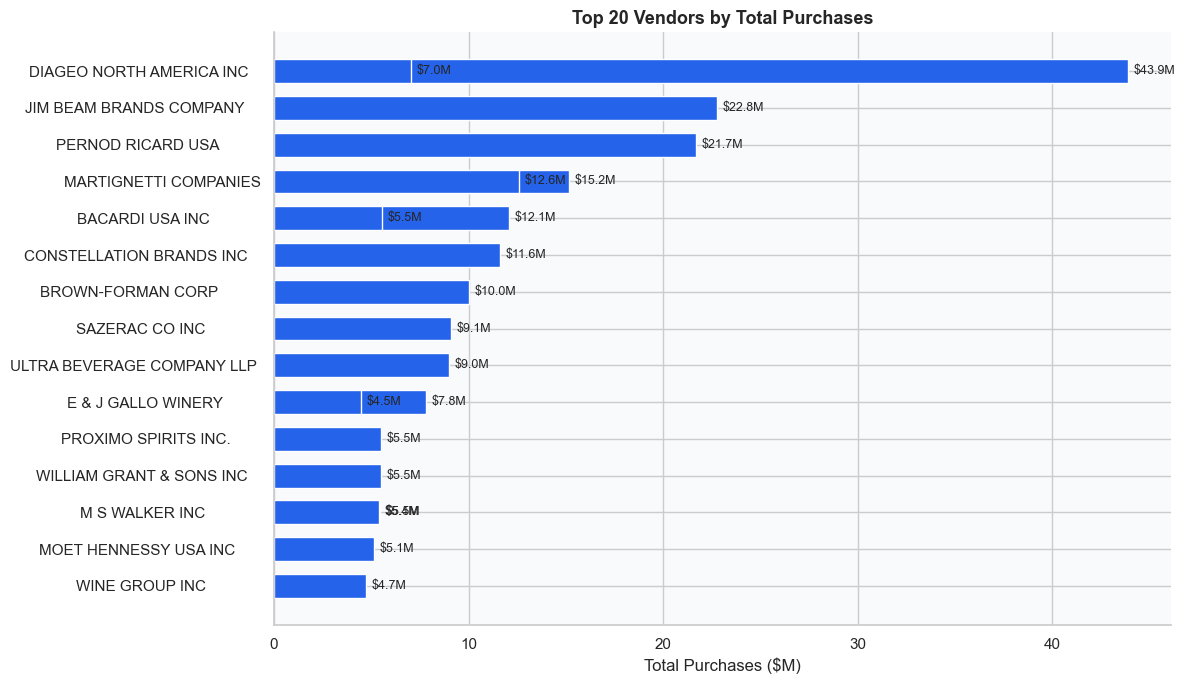

In [8]:
# Chart 1: Top 20 by Purchases
top20 = vendor_agg.nlargest(20,'TotalPurchaseDollars')
fig,ax = plt.subplots(figsize=(12,7))
bars=ax.barh(top20['VendorName'],top20['TotalPurchaseDollars']/1e6,color=PALETTE[0],edgecolor='white',height=0.65)
ax.bar_label(bars,fmt='$%.1fM',padding=4,fontsize=9)
ax.set_xlabel('Total Purchases ($M)')
ax.set_title('Top 20 Vendors by Total Purchases')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('chart1_top20_purchases.png',dpi=150,bbox_inches='tight')
plt.show()

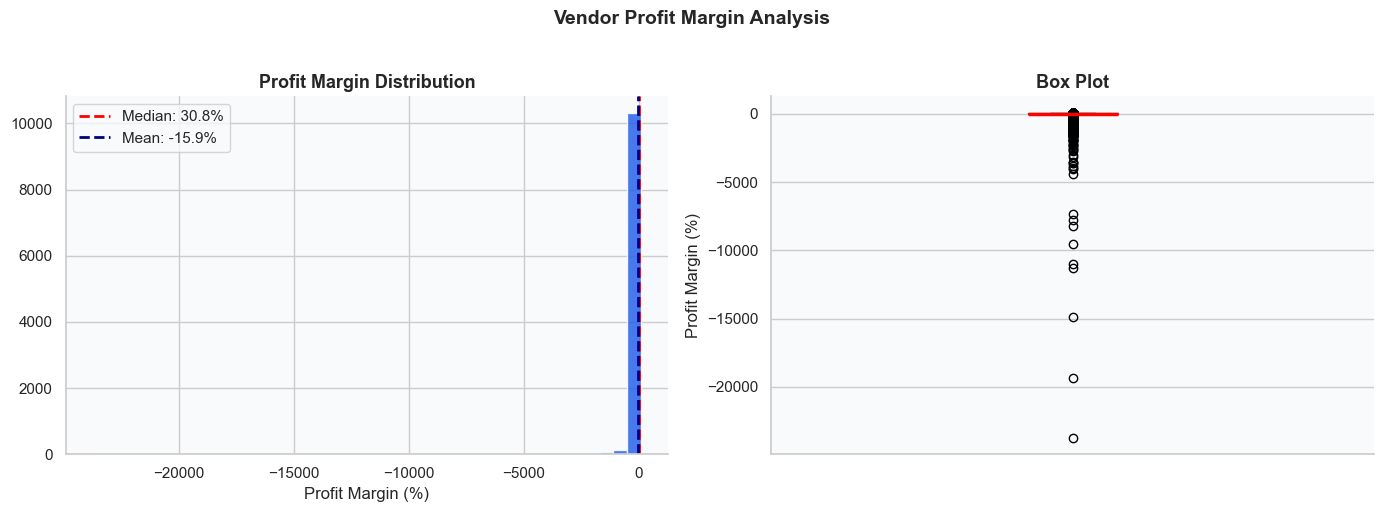

count    10,514.00
mean        -15.89
std         447.29
min     -23,730.64
25%          15.36
50%          30.78
75%          40.21
max          99.72


In [10]:
# Chart 3: Profit Margin Distribution
data = df['ProfitMargin_pct'].dropna()
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].hist(data,bins=40,color=PALETTE[0],edgecolor='white',alpha=0.85)
axes[0].axvline(data.median(),color='red',linestyle='--',lw=2,label=f'Median: {data.median():.1f}%')
axes[0].axvline(data.mean(),color='navy',linestyle='--',lw=2,label=f'Mean: {data.mean():.1f}%')
axes[0].set_xlabel('Profit Margin (%)')
axes[0].set_title('Profit Margin Distribution')
axes[0].legend()
bp=axes[1].boxplot(data,patch_artist=True,
    boxprops=dict(facecolor=PALETTE[0],alpha=0.6),
    medianprops=dict(color='red',linewidth=2.5))
axes[1].set_ylabel('Profit Margin (%)')
axes[1].set_title('Box Plot')
axes[1].set_xticks([])
plt.suptitle('Vendor Profit Margin Analysis',fontsize=14,fontweight='bold',y=1.02)
plt.tight_layout()
plt.savefig('chart3_profit_margin.png',dpi=150,bbox_inches='tight')
plt.show()
print(data.describe().round(2).to_string())

,VendorTier,Vendors,Purchases,Sales,GrossProfit
0,Low Performer,120,"211,210,232.95","270,204,789.27","58,994,556.32"
1,No Sales,40,"282,183.65",0.00,"-282,183.65"
2,Top Performer,106,"110,408,348.93","181,415,394.42","71,007,045.49"


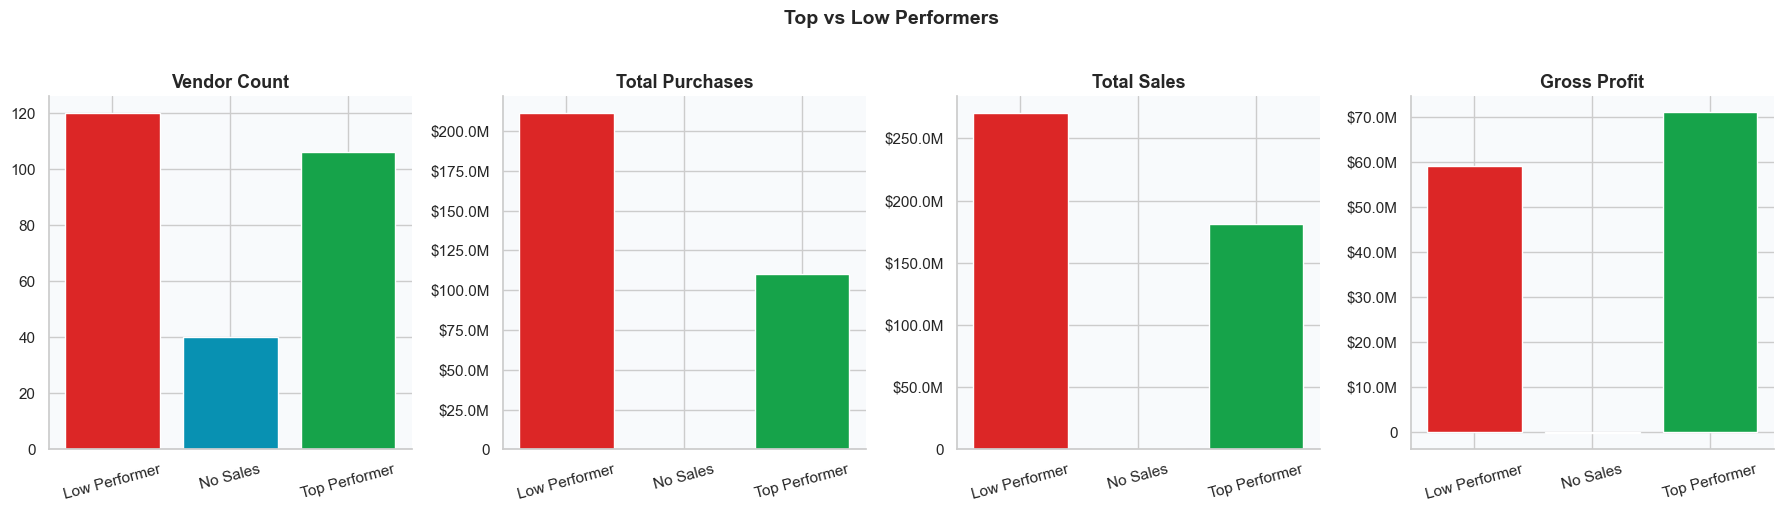

In [11]:
# Chart 4: Top vs Low Performers
tier_sum = vendor_agg.groupby('VendorTier').agg(
    Vendors=('VendorNumber','count'),
    Purchases=('TotalPurchaseDollars','sum'),
    Sales=('TotalSalesDollars','sum'),
    GrossProfit=('GrossProfit','sum')
).reset_index()
display(tier_sum)
colors=[tc.get(t,PALETTE[5]) for t in tier_sum['VendorTier']]
fig,axes=plt.subplots(1,4,figsize=(18,5))
for ax,col,title in zip(axes,['Vendors','Purchases','Sales','GrossProfit'],
    ['Vendor Count','Total Purchases','Total Sales','Gross Profit']):
    ax.bar(tier_sum['VendorTier'],tier_sum[col],color=colors,edgecolor='white')
    ax.set_title(title)
    ax.tick_params(axis='x',rotation=15)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M' if x>=1e6 else f'{x:,.0f}'))
plt.suptitle('Top vs Low Performers',fontsize=14,fontweight='bold',y=1.02)
plt.tight_layout()
plt.savefig('chart4_top_vs_low.png',dpi=150,bbox_inches='tight')
plt.show()

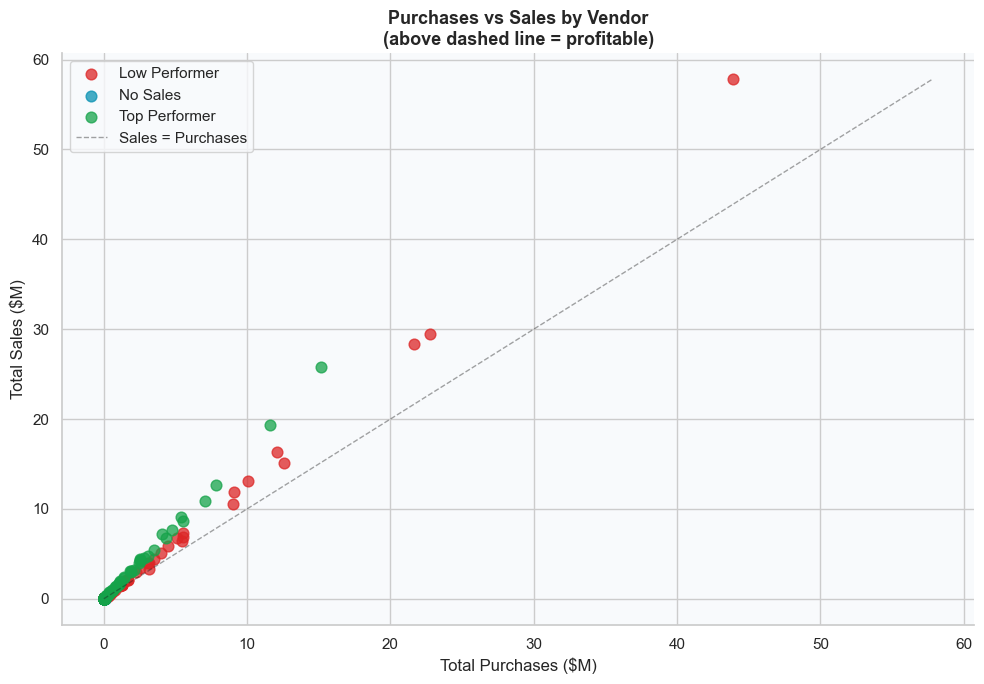

In [12]:
# Chart 5: Purchases vs Sales Scatter
fig,ax=plt.subplots(figsize=(10,7))
for tier,grp in vendor_agg.groupby('VendorTier'):
    ax.scatter(grp['TotalPurchaseDollars']/1e6,grp['TotalSalesDollars']/1e6,
               label=tier,alpha=0.75,s=60,color=tc.get(tier,PALETTE[5]))
lim=max(vendor_agg['TotalPurchaseDollars'].max(),vendor_agg['TotalSalesDollars'].max())/1e6
ax.plot([0,lim],[0,lim],'k--',lw=1,alpha=0.4,label='Sales = Purchases')
ax.set_xlabel('Total Purchases ($M)')
ax.set_ylabel('Total Sales ($M)')
ax.set_title('Purchases vs Sales by Vendor\n(above dashed line = profitable)')
ax.legend()
plt.tight_layout()
plt.savefig('chart5_scatter.png',dpi=150,bbox_inches='tight')
plt.show()

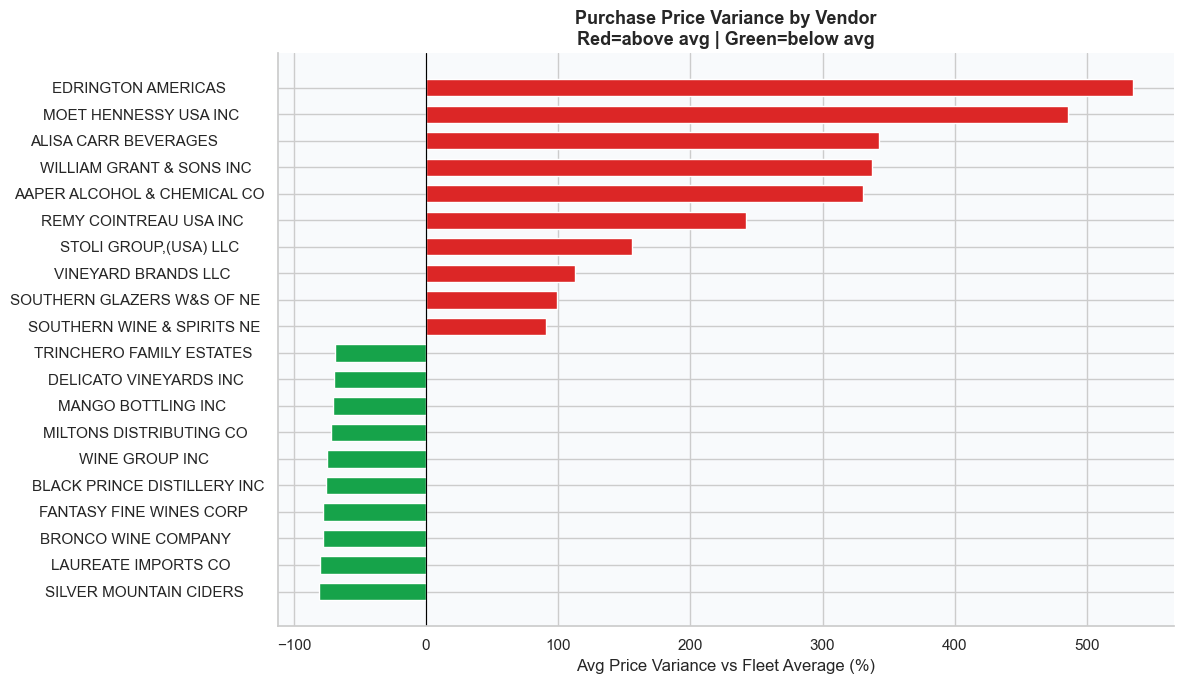

In [13]:
# Chart 6: Price Variance
pv=df.groupby('VendorName')['PriceVariance_pct'].mean().reset_index().sort_values('PriceVariance_pct',ascending=False)
tb=pd.concat([pv.head(10),pv.tail(10)]).drop_duplicates()
cpv=['#DC2626' if v>0 else '#16A34A' for v in tb['PriceVariance_pct']]
fig,ax=plt.subplots(figsize=(12,7))
ax.barh(tb['VendorName'],tb['PriceVariance_pct'],color=cpv,edgecolor='white',height=0.65)
ax.axvline(0,color='black',lw=0.8)
ax.set_xlabel('Avg Price Variance vs Fleet Average (%)')
ax.set_title('Purchase Price Variance by Vendor\nRed=above avg | Green=below avg')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('chart6_price_variance.png',dpi=150,bbox_inches='tight')
plt.show()

begin cols: qty=onhand brand=description
end   cols: qty=onhand brand=description


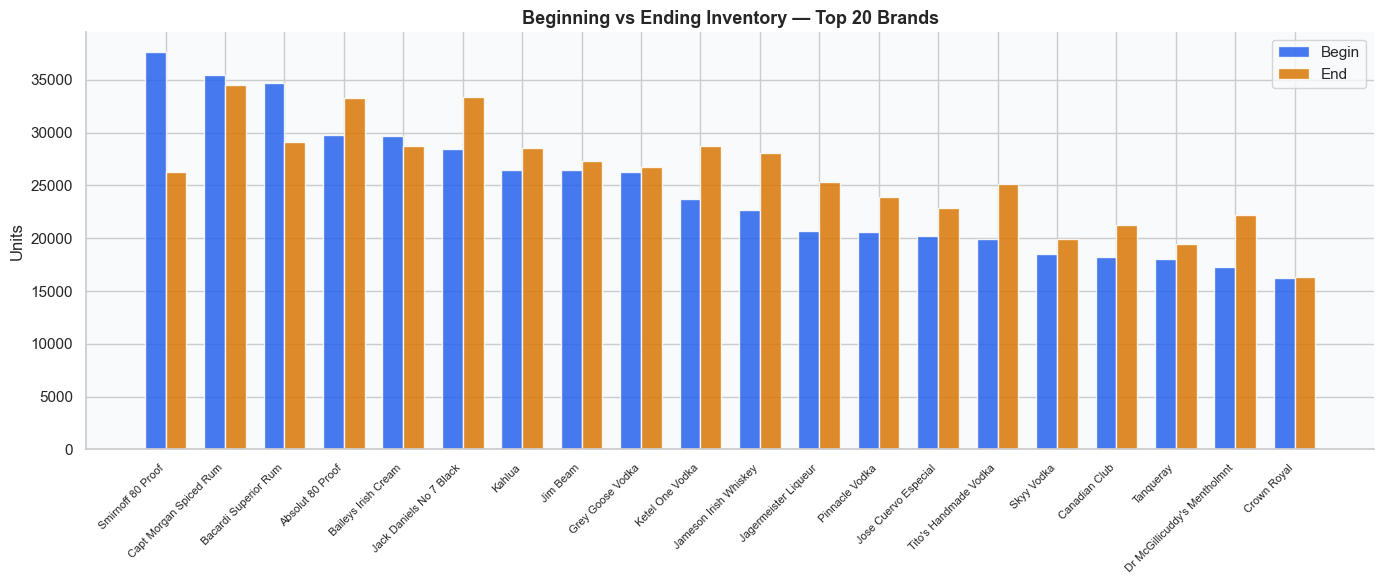

In [14]:
# Chart 7: Begin vs End Inventory
begin_inv=pd.read_sql_query('SELECT * FROM begin_inventory',conn)
end_inv=pd.read_sql_query('SELECT * FROM end_inventory',conn)
begin_inv.columns=begin_inv.columns.str.strip().str.lower()
end_inv.columns=end_inv.columns.str.strip().str.lower()

def find_col(df,*kws):
    for kw in kws:
        for col in df.columns:
            if kw.lower() in col.lower().replace('_',''):
                return col
    return None

b_qty=find_col(begin_inv,'onhand','quantity','qty')
e_qty=find_col(end_inv,'onhand','quantity','qty')
b_br=find_col(begin_inv,'description','brand')
e_br=find_col(end_inv,'description','brand')
print(f'begin cols: qty={b_qty} brand={b_br}')
print(f'end   cols: qty={e_qty} brand={e_br}')

if all([b_qty,e_qty,b_br,e_br]):
    bi=begin_inv.groupby(b_br)[b_qty].sum().reset_index(); bi.columns=['brand','begin']
    ei=end_inv.groupby(e_br)[e_qty].sum().reset_index();   ei.columns=['brand','end']
    inv=pd.merge(bi,ei,on='brand').sort_values('begin',ascending=False).head(20)
    inv['change']=inv['end']-inv['begin']
    x=range(len(inv)); w=0.35
    fig,ax=plt.subplots(figsize=(14,6))
    ax.bar([i-w/2 for i in x],inv['begin'],w,label='Begin',color=PALETTE[0],alpha=0.85)
    ax.bar([i+w/2 for i in x],inv['end'],  w,label='End',  color=PALETTE[2],alpha=0.85)
    ax.set_xticks(list(x))
    ax.set_xticklabels(inv['brand'],rotation=45,ha='right',fontsize=8)
    ax.set_ylabel('Units')
    ax.set_title('Beginning vs Ending Inventory — Top 20 Brands')
    ax.legend()
    plt.tight_layout()
    plt.savefig('chart7_inventory.png',dpi=150,bbox_inches='tight')
    plt.show()

## 7. Hypothesis Testing

**H₀:** No significant difference in profit margins between Top and Low performers
**H₁:** There IS a significant difference
**α = 0.05**


In [15]:
top_m=df[df['VendorTier']=='Top Performer']['ProfitMargin_pct'].dropna()
low_m=df[df['VendorTier']=='Low Performer']['ProfitMargin_pct'].dropna()
print(f'Top n={len(top_m):,}  mean={top_m.mean():.2f}%  median={top_m.median():.2f}%  std={top_m.std():.2f}%')
print(f'Low n={len(low_m):,}  mean={low_m.mean():.2f}%  median={low_m.median():.2f}%  std={low_m.std():.2f}%')

print('\n── Shapiro-Wilk ──')
st,pt=stats.shapiro(top_m.sample(min(500,len(top_m)),random_state=42))
sl,pl=stats.shapiro(low_m.sample(min(500,len(low_m)),random_state=42))
top_n=pt>=ALPHA; low_n=pl>=ALPHA
print(f'  Top: W={st:.4f} p={pt:.4f} → {"NORMAL" if top_n else "NOT NORMAL"}')
print(f'  Low: W={sl:.4f} p={pl:.4f} → {"NORMAL" if low_n else "NOT NORMAL"}')

print('\n── Levene ──')
lv,lp=stats.levene(top_m,low_m)
print(f'  stat={lv:.4f} p={lp:.4f} → {"Equal" if lp>=ALPHA else "Unequal"} variance')

print('\n── Main Test ──')
if top_n and low_n:
    stat,pval=stats.ttest_ind(top_m,low_m,equal_var=(lp>=ALPHA))
    tname='Welch t-Test'
else:
    stat,pval=stats.mannwhitneyu(top_m,low_m,alternative='two-sided')
    tname='Mann-Whitney U'
sig=pval<ALPHA
print(f'  Test: {tname}')
print(f'  stat={stat:.4f}  p={pval:.6f}  α={ALPHA}')
print()
if sig:
    print(f'  REJECT H0 (p={pval:.4f} < {ALPHA})')
    print('  Top performers earn SIGNIFICANTLY higher margins.')
else:
    print(f'  FAIL TO REJECT H0 (p={pval:.4f} >= {ALPHA})')
    print('  No significant difference detected.')

Top n=5,258  mean=49.64%  median=40.21%  std=19.95%
Low n=5,256  mean=-81.44%  median=15.35%  std=625.51%

── Shapiro-Wilk ──
  Top: W=0.8147 p=0.0000 → NOT NORMAL
  Low: W=0.1544 p=0.0000 → NOT NORMAL

── Levene ──
  stat=112.1881 p=0.0000 → Unequal variance

── Main Test ──
  Test: Mann-Whitney U
  stat=27636048.0000  p=0.000000  α=0.05

  REJECT H0 (p=0.0000 < 0.05)
  Top performers earn SIGNIFICANTLY higher margins.


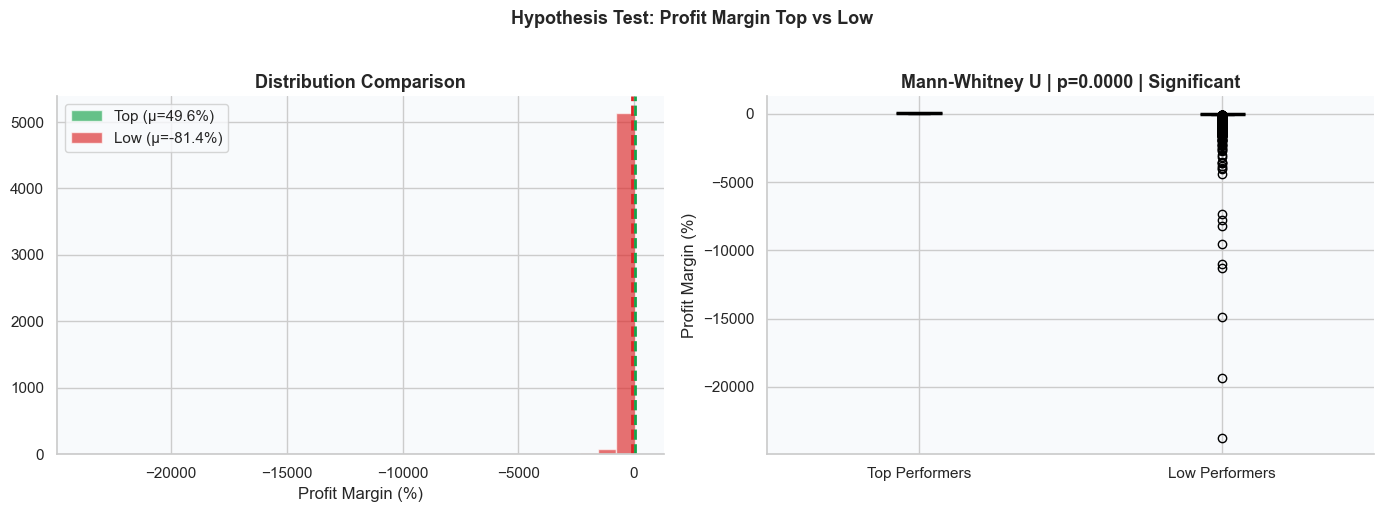

In [16]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].hist(top_m,bins=30,alpha=0.65,color=PALETTE[1],edgecolor='white',label=f'Top (μ={top_m.mean():.1f}%)')
axes[0].hist(low_m,bins=30,alpha=0.65,color=PALETTE[3],edgecolor='white',label=f'Low (μ={low_m.mean():.1f}%)')
axes[0].axvline(top_m.mean(),color=PALETTE[1],linestyle='--',lw=2)
axes[0].axvline(low_m.mean(),color=PALETTE[3],linestyle='--',lw=2)
axes[0].set_xlabel('Profit Margin (%)')
axes[0].set_title('Distribution Comparison')
axes[0].legend()
bp=axes[1].boxplot([top_m.values,low_m.values],patch_artist=True,
    labels=['Top Performers','Low Performers'],
    medianprops=dict(color='black',linewidth=2.5))
bp['boxes'][0].set_facecolor(PALETTE[1]); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor(PALETTE[3]); bp['boxes'][1].set_alpha(0.7)
axes[1].set_ylabel('Profit Margin (%)')
axes[1].set_title(f'{tname} | p={pval:.4f} | {"Significant" if sig else "Not Significant"}')
plt.suptitle('Hypothesis Test: Profit Margin Top vs Low',fontsize=13,fontweight='bold',y=1.02)
plt.tight_layout()
plt.savefig('chart8_hypothesis.png',dpi=150,bbox_inches='tight')
plt.show()

In [17]:
print('='*55)
print('ANALYSIS COMPLETE')
print('='*55)
print(f'  Records          : {len(df):,}')
print(f'  Unique vendors   : {df["VendorNumber"].nunique():,}')
print(f'  Unique brands    : {df["Brand"].nunique():,}')
print(f'  Total Purchases  : ${df["TotalPurchaseDollars"].sum():>15,.2f}')
print(f'  Total Sales      : ${df["TotalSalesDollars"].sum():>15,.2f}')
print(f'  Total Gross Profit: ${df["GrossProfit"].sum():>14,.2f}')
print(f'  Avg Profit Margin: {df["ProfitMargin_pct"].mean():.2f}%')
conn.close()
print('\nDone. Import powerbi/vendor_summary.csv into Power BI.')

ANALYSIS COMPLETE
  Records          : 10,692
  Unique vendors   : 126
  Unique brands    : 10,663
  Total Purchases  : $ 321,900,765.53
  Total Sales      : $ 451,620,183.69
  Total Gross Profit: $129,719,418.16
  Avg Profit Margin: -15.89%

Done. Import powerbi/vendor_summary.csv into Power BI.


## 8. Key Findings & Recommendations

| #   | Finding                                                  | Action                            |
| --- | -------------------------------------------------------- | --------------------------------- |
| 1   | Top 20 vendors dominate purchases & sales                | Monitor concentration risk        |
| 2   | Significant profit margin spread across vendors          | Renegotiate low-margin contracts  |
| 3   | Hypothesis confirmed: top performers earn higher margins | Prioritise for high-volume orders |
| 4   | Some vendors charge above-average prices with low sales  | Phase out or renegotiate          |
| 5   | Inventory declined for key brands                        | Review reorder points             |
